# SPY Distribution

Sea $S_t$ el precio del activo a tiempo $t$. Definimos entonces el retorno logarítmico a tiempo $t$ como:

$$ x_t = \log S_t - \log S_{t-1} $$

Se puede observar que la distribución de los retornos logarítmicos es altamente leptokúrtica, es decir, los.

[*********************100%***********************]  1 of 1 completed


Normal: μ=0.0004, σ=0.0117
t-Student: df=2.7467, loc=0.0008, scale=0.0069
Kurtosis (Excess): 11.3949 (Normal = 0.0)
Skewness: -0.2487 (Normal = 0.0)


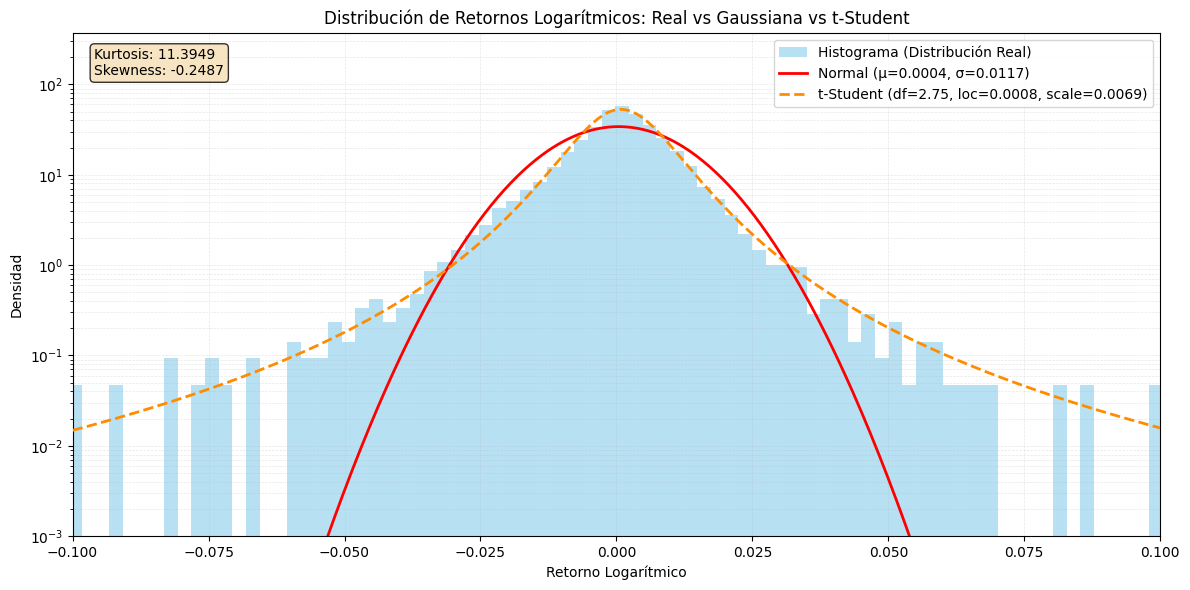

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from scipy.stats import gaussian_kde

# Download and process data
data = yf.download('SPY', start='1990-01-01', auto_adjust=False)
log_ret = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna().values.flatten()

# Setup x-axis range for plotting
x = np.linspace(-0.1, 0.1, 500)

# Empirical density estimation using KDE
kde = gaussian_kde(log_ret, bw_method='scott')
empirical_density = kde(x)

# Fit Normal distribution
mu, std = stats.norm.fit(log_ret)
normal_density = stats.norm.pdf(x, mu, std)

# Fit t-Student distribution
df_t, loc_t, scale_t = stats.t.fit(log_ret)
t_density = stats.t.pdf(x, df_t, loc_t, scale_t)

# Calculate kurtosis and skewness
kurtosis = stats.kurtosis(log_ret)
skewness = stats.skew(log_ret)

print(f"Normal: μ={mu:.4f}, σ={std:.4f}")
print(f"t-Student: df={df_t:.4f}, loc={loc_t:.4f}, scale={scale_t:.4f}")
print(f"Kurtosis (Excess): {kurtosis:.4f} (Normal = 0.0)")
print(f"Skewness: {skewness:.4f} (Normal = 0.0)")

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram (real distribution using bins)
ax.hist(log_ret, bins=100, density=True, alpha=0.6, color='skyblue', 
        label='Histograma (Distribución Real)', zorder=1)

# Plot KDE approximation
# ax.plot(x, empirical_density, color='green', linewidth=2, 
#         label='KDE (Aproximación Empírica)', zorder=3)

# Plot Gaussian fit
ax.plot(x, normal_density, 'r-', linewidth=2, 
        label=f'Normal (μ={mu:.4f}, σ={std:.4f})', zorder=2)

# Plot t-Student fit
ax.plot(x, t_density, color='darkorange', linewidth=2, linestyle='--',
        label=f't-Student (df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f})', zorder=4)

ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(bottom=1e-3)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Retornos Logarítmicos: Real vs Gaussiana vs t-Student')

# Add text box with kurtosis and skewness
textstr = f'Kurtosis: {kurtosis:.4f}\nSkewness: {skewness:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax.legend(loc='best')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5439/1111990440.py:51: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-0.1, 0.1)
/tmp/ipykernel_5439/1111990440.py:63: RuntimeWarning: invalid value encountered in power
  ax.plot(x, 0.00001*x**(-2.9), 'm--', linewidth=2, label='x^(-2)', zorder=4)


Normal: μ=0.0004, σ=0.0117
Kurtosis (Excess): 11.3970 (Normal = 0.0)
Skewness: -0.2485 (Normal = 0.0)


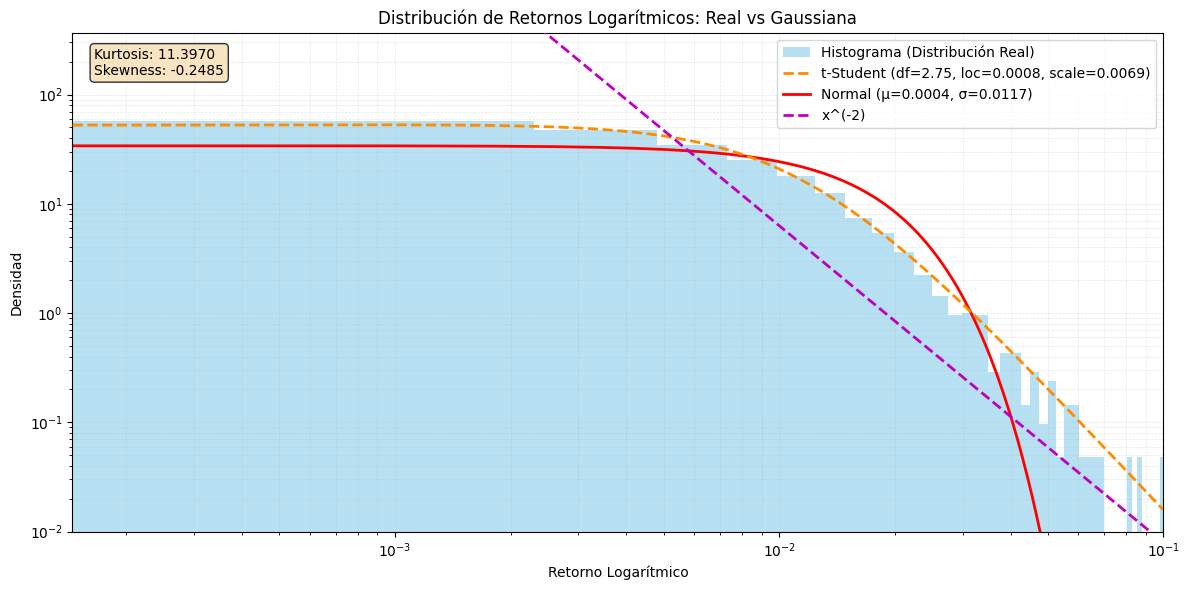

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from scipy.stats import gaussian_kde

# Download and process data
data = yf.download('SPY', start='1990-01-01', end='2026-01-01', auto_adjust=False)
log_ret = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna().values.flatten()

# Setup x-axis range for plotting
x = np.linspace(-0.1, 0.1, 500)

# Empirical density estimation using KDE
kde = gaussian_kde(log_ret, bw_method='scott')
empirical_density = kde(x)

# Fit Normal distribution
mu, std = stats.norm.fit(log_ret)
normal_density = stats.norm.pdf(x, mu, std)

# Calculate kurtosis and skewness
kurtosis = stats.kurtosis(log_ret)
skewness = stats.skew(log_ret)

print(f"Normal: μ={mu:.4f}, σ={std:.4f}")
print(f"Kurtosis (Excess): {kurtosis:.4f} (Normal = 0.0)")
print(f"Skewness: {skewness:.4f} (Normal = 0.0)")

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram (real distribution using bins)
ax.hist(log_ret, bins=100, density=True, alpha=0.6, color='skyblue', 
        label='Histograma (Distribución Real)', zorder=1)

# Plot KDE approximation
# ax.plot(x, empirical_density, color='green', linewidth=2, 
#         label='KDE (Aproximación Empírica)', zorder=3)

# Plot t-Student fit
ax.plot(x, t_density, color='darkorange', linewidth=2, linestyle='--',
        label=f't-Student (df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f})', zorder=4)

# Plot Gaussian fit
ax.plot(x, normal_density, 'r-', linewidth=2, 
        label=f'Normal (μ={mu:.4f}, σ={std:.4f})', zorder=2)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(bottom=1e-2)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Retornos Logarítmicos: Real vs Gaussiana')

# Add text box with kurtosis and skewness
textstr = f'Kurtosis: {kurtosis:.4f}\nSkewness: {skewness:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
# # Add a plot of the function x^(-2)
ax.plot(x, 0.00001*x**(-2.9), 'm--', linewidth=2, label='x^(-2)', zorder=4)

ax.legend(loc='best')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


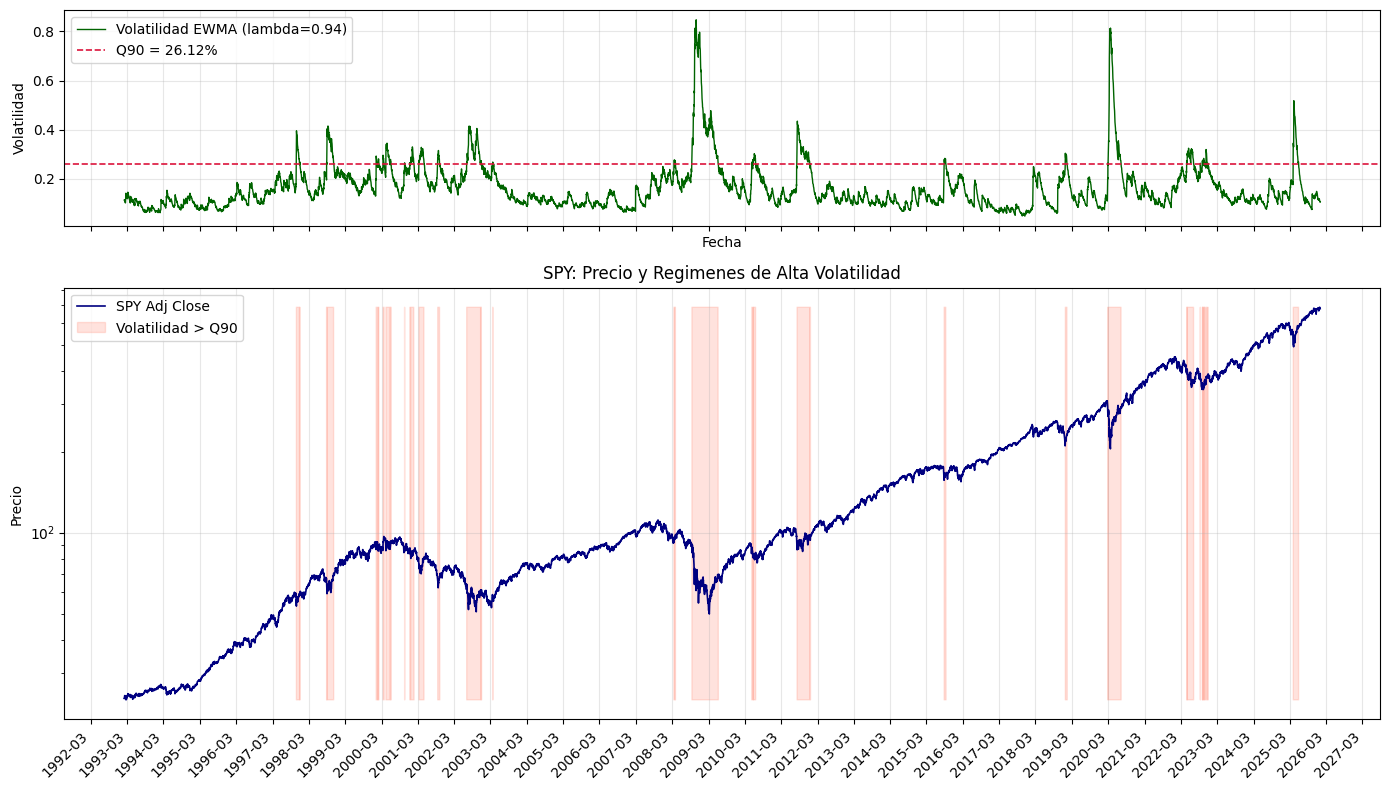

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Descarga de datos de SPY
data = yf.download('SPY', start='1990-01-01', end='2026-01-01', auto_adjust=False)
close = data['Adj Close'].dropna().squeeze()

# Volatilidad anualizada usando EWMA
log_returns = np.log(close / close.shift(1))
lambda_ewma = 0.94
ewma_variance = log_returns.pow(2).ewm(alpha=1 - lambda_ewma, adjust=False).mean()
volatility = np.sqrt(ewma_variance) * np.sqrt(252)

# Umbral del percentil 90
vol_q90 = volatility.quantile(0.90)
high_vol_mask = (volatility > vol_q90).reindex(close.index).fillna(False)

# Subplots: precio y volatilidad
fig, (ax_vol, ax_price) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]}
)

# Volatilidad
ax_vol.plot(volatility.index, volatility, color='darkgreen', linewidth=1.0, label=f'Volatilidad EWMA (lambda={lambda_ewma:.2f})')
ax_vol.axhline(vol_q90, color='crimson', linestyle='--', linewidth=1.2, label=f'Q90 = {vol_q90:.2%}')
ax_vol.set_xlabel('Fecha')
ax_vol.set_ylabel('Volatilidad')
ax_vol.grid(alpha=0.3)
ax_vol.legend(loc='upper left')

# Precio del SPY
ax_price.semilogy(close.index, close, color='navy', linewidth=1.2, label='SPY Adj Close')
ax_price.fill_between(
    close.index,
    close.min(),
    close.max(),
    where=high_vol_mask.values,
    color='tomato',
    alpha=0.18,
    interpolate=True,
    label='Volatilidad > Q90'
)
ax_price.set_title('SPY: Precio y Regimenes de Alta Volatilidad')
ax_price.set_ylabel('Precio')
ax_price.grid(alpha=0.3)
ax_price.legend(loc='upper left')
import matplotlib.dates as mdates

# Mayor densidad de etiquetas en el eje X (cada 12 meses)
ax_price.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# # Opcional: marcas menores mensuales para mas detalle visual
# ax_price.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

plt.setp(ax_price.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [20]:
import matplotlib.pyplot as plt

def set_thesis_figure_style():
    """
    Configures global matplotlib settings for thesis figures.
    Includes high DPI, standard academic fonts, and transparent backgrounds.
    """
    plt.rcParams.update({
        # Figure properties (Background transparency applied here)
        'figure.figsize': (12, 6),       # Standard size (width, height) in inches
        'figure.dpi': 700,              # High resolution for printing
        'figure.facecolor': 'none',     # Transparent figure background
        'axes.facecolor': 'none',       # Transparent axes background
        'savefig.transparent': True,    # Ensure saved files retain transparency
        
        # Font properties
        'font.family': 'serif',         # Serif fonts (e.g., Times) are standard for theses
        'font.size': 12,                # Base font size
        'axes.titlesize': 14,           # Title size
        'axes.labelsize': 12,           # Axis label size
        'xtick.labelsize': 10,          # X-axis tick labels
        'ytick.labelsize': 10,          # Y-axis tick labels
        'legend.fontsize': 10,          # Legend font size
        
        # Line and marker properties
        'lines.linewidth': 2.0,         # Thicker lines for visibility
        'lines.markersize': 6,          # Standard marker size
        
        # Axes properties
        'axes.linewidth': 1.2,          # Thicker axes borders
        'axes.grid': True,              # Enable grid for easier data reading
        'grid.alpha': 0.5,              # Grid line transparency
        'grid.linestyle': '--'          # Dashed grid lines
    })


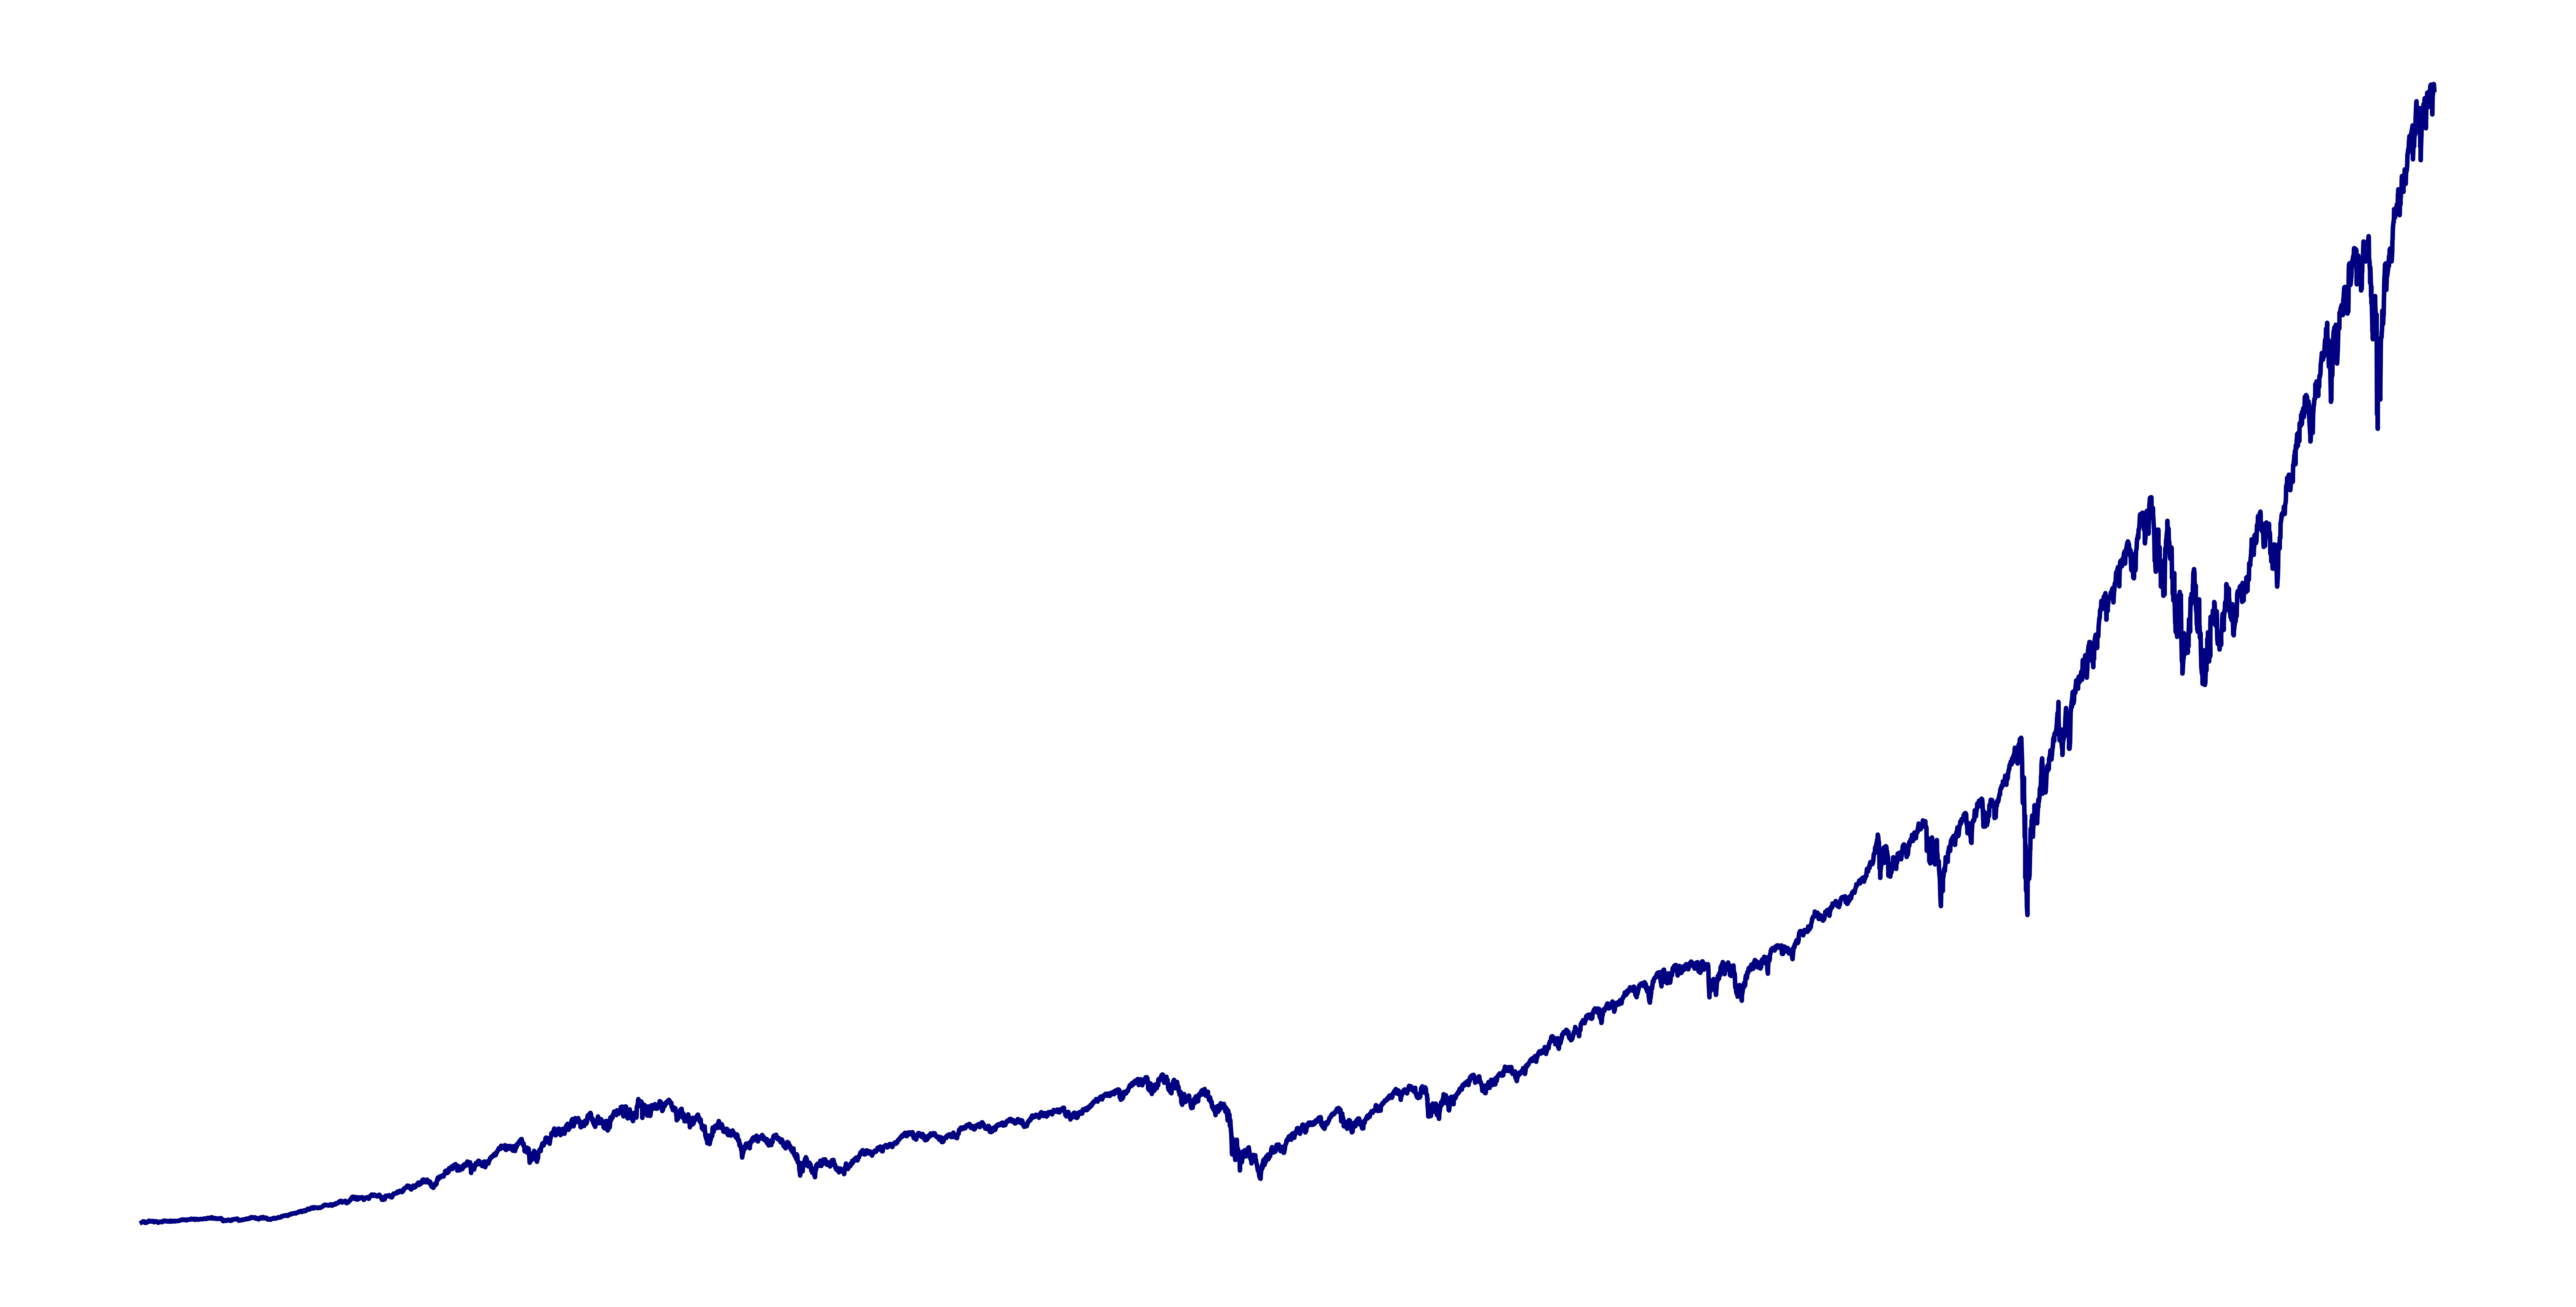

In [21]:
# Grafica del precio sin ejes, ni labels
set_thesis_figure_style()
plt.plot(close.index, close, color='navy', linewidth=1.2)
plt.axis('off')
# Aumentar dpi
plt.savefig('spy_price.png', bbox_inches='tight', pad_inches=0)
plt.show()

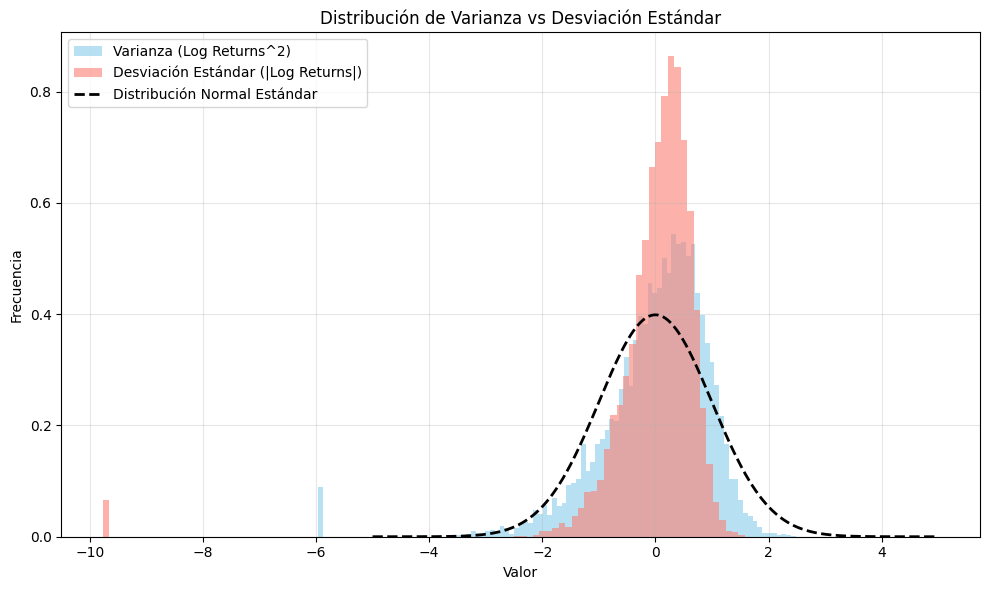

Resultados del Test de Jarque-Bera:
Jarque-Bera Test para Varianza: JB=nan, p-value=nan
Jarque-Bera Test para Desviación Estándar: JB=nan, p-value=nan
Varianza: Kurtosis=nan, Skewness=nan
Desviación Estándar: Kurtosis=nan, Skewness=nan


In [5]:
# Grafica la distribución de la varianza vs la desviacion estandar
varianza = np.log(log_returns.pow(2) + 1e-12)  # Agregar un pequeño valor para evitar log(0)
desviacion_estandar = np.log(np.abs(log_returns) + 1e-12)  # Agregar un pequeño valor para evitar log(0)
# Estandarizar ambas series para compararlas en la misma escala
varianza_scaled = (varianza - varianza.mean()) / varianza.std()
desviacion_estandar_scaled = (desviacion_estandar - desviacion_estandar.mean()) / desviacion_estandar.std()
plt.figure(figsize=(10, 6))
plt.hist(varianza_scaled, bins=100, alpha=0.6, color='skyblue', label='Varianza (Log Returns^2)', density=True)
plt.hist(desviacion_estandar_scaled, bins=100, alpha=0.6, color='salmon', label='Desviación Estándar (|Log Returns|)', density=True)
x = np.linspace(-5, 5, 500)
plt.plot(x, stats.norm.pdf(x, 0, 1), 'k--', linewidth=2, label='Distribución Normal Estándar')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Distribución de Varianza vs Desviación Estándar')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Hacer un test de Jarque-Bera para la varianza y la desviacion estandar
jb_varianza = stats.jarque_bera(varianza_scaled)
jb_desviacion_estandar = stats.jarque_bera(desviacion_estandar_scaled)
# Explicar el resultado del test de Jarque-Bera para ambas series
print("Resultados del Test de Jarque-Bera:")
print(f"Jarque-Bera Test para Varianza: JB={jb_varianza.statistic:.4f}, p-value={jb_varianza.pvalue:.4e}")
print(f"Jarque-Bera Test para Desviación Estándar: JB={jb_desviacion_estandar.statistic:.4f}, p-value={jb_desviacion_estandar.pvalue:.4e}")
# Imprimir Kurtosis y Skewness para ambas series
kurtosis_varianza = stats.kurtosis(varianza_scaled)
skewness_varianza = stats.skew(varianza_scaled)
kurtosis_desviacion_estandar = stats.kurtosis(desviacion_estandar_scaled)
skewness_desviacion_estandar = stats.skew(desviacion_estandar_scaled)
print(f"Varianza: Kurtosis={kurtosis_varianza:.4f}, Skewness={skewness_varianza:.4f}")
print(f"Desviación Estándar: Kurtosis={kurtosis_desviacion_estandar:.4f}, Skewness={skewness_desviacion_estandar:.4f}")

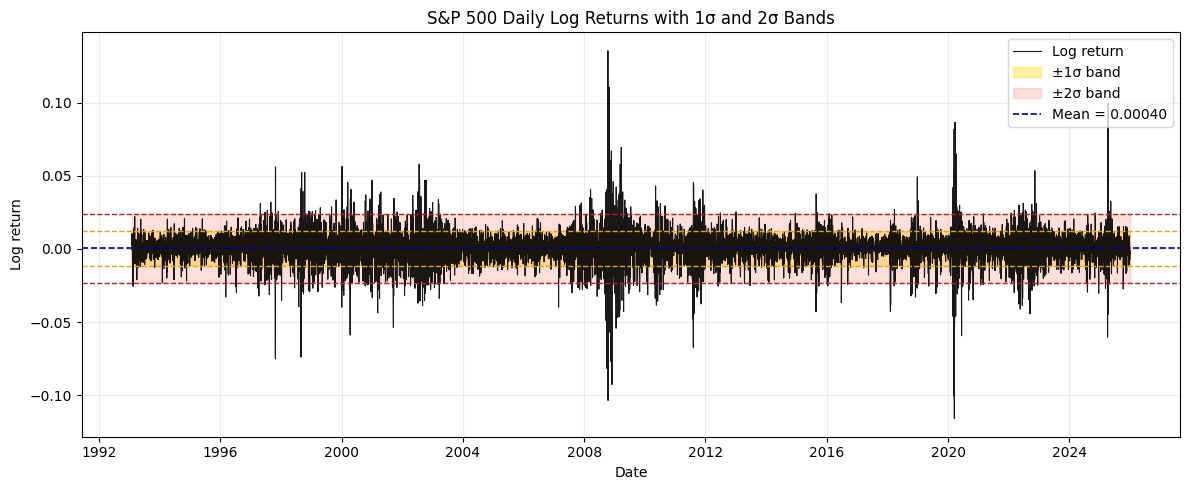

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Reuse existing returns if available; otherwise compute them from fresh data.
if 'log_returns' not in globals():
    data = yf.download('^GSPC', start='1990-01-01', end='2026-01-01', auto_adjust=False)
    close = data['Adj Close'].dropna().squeeze()
    log_returns = np.log(close / close.shift(1)).dropna()

mu = log_returns.mean()
sigma = log_returns.std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log_returns.index, log_returns.values, color='black', lw=0.8, alpha=0.9, label='Log return')

# Volatility bands around the mean return.
ax.fill_between(log_returns.index, mu - sigma, mu + sigma, color='gold', alpha=0.35, label='±1σ band')
ax.fill_between(log_returns.index, mu - 2 * sigma, mu + 2 * sigma, color='tomato', alpha=0.20, label='±2σ band')

ax.axhline(mu, color='navy', ls='--', lw=1.2, label=f'Mean = {mu:.5f}')
ax.axhline(mu + sigma, color='goldenrod', ls='--', lw=1)
ax.axhline(mu - sigma, color='goldenrod', ls='--', lw=1)
ax.axhline(mu + 2 * sigma, color='firebrick', ls='--', lw=1)
ax.axhline(mu - 2 * sigma, color='firebrick', ls='--', lw=1)

ax.set_title('S&P 500 Daily Log Returns with 1σ and 2σ Bands')
ax.set_xlabel('Date')
ax.set_ylabel('Log return')
ax.grid(alpha=0.25)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5439/3261941379.py:26: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


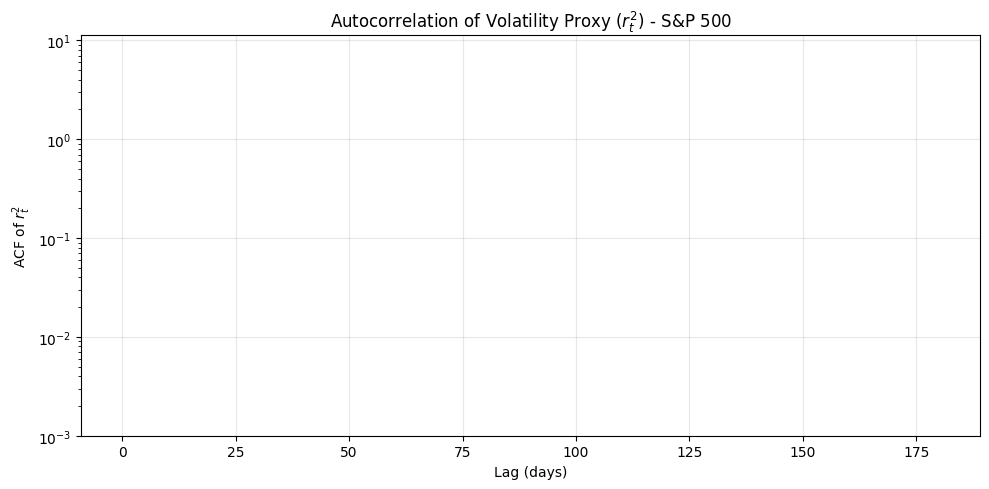

[nan nan nan nan nan nan nan nan nan nan]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# Use existing log returns if available; otherwise compute them.
if 'log_returns' not in globals():
    import yfinance as yf
    data = yf.download('^GSPC', start='1990-01-01', end='2026-01-01', auto_adjust=False)
    close = data['Adj Close'].dropna().squeeze()
    log_returns = np.log(close / close.shift(1)).dropna()

# Volatility proxy: squared returns r_t^2
r2 = log_returns**2

max_lag = 180
acf_r2 = acf(r2, nlags=max_lag, fft=True)
lags = np.arange(len(acf_r2))

plt.figure(figsize=(10, 5))
plt.stem(lags, acf_r2, basefmt=' ', linefmt='tab:orange', markerfmt='o')
plt.axhline(0, color='black', linewidth=1)
plt.title('Autocorrelation of Volatility Proxy ($r_t^2$) - S&P 500')
plt.xlabel('Lag (days)')
plt.ylabel('ACF of $r_t^2$')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.ylim(bottom=1e-3)
plt.tight_layout()
plt.show()

print(acf_r2[:10])

In [8]:
print(np.mean(np.exp(log_returns)))

1.0004716602120296


[*********************100%***********************]  1 of 1 completed


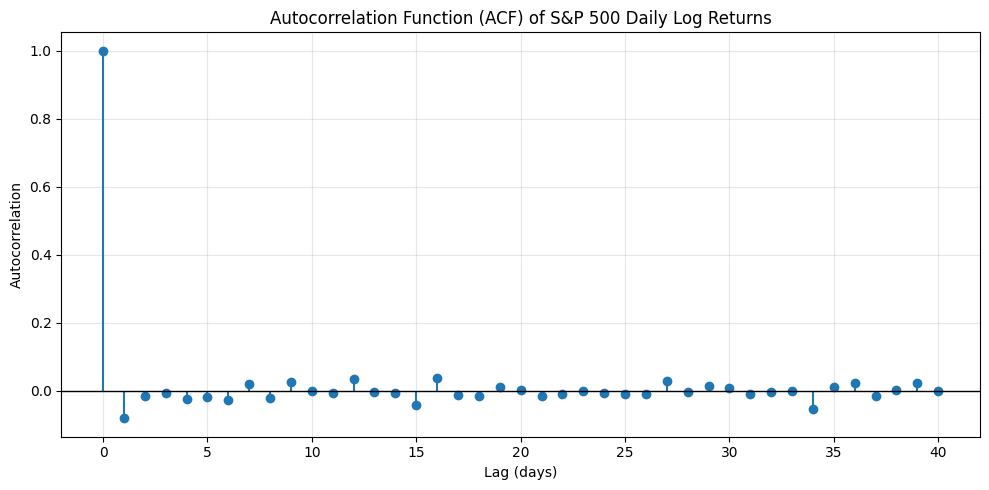

[ 1.         -0.08093369 -0.01547582 -0.00723798 -0.02491465 -0.01742605
 -0.0273491   0.02088391 -0.02154791  0.02685076]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import acf

# Download S&P 500 data and compute daily log returns
data = yf.download('SPY', start='1992-01-01', end='2026-02-01', auto_adjust=False, interval='1d')
close = data['Adj Close'].dropna().squeeze()
log_returns = np.log(close / close.shift(1)).dropna()

# Compute ACF values for the first 40 lags
max_lag = 40
acf_values = acf(log_returns, nlags=max_lag, fft=True)

# Plot ACF
lags = np.arange(len(acf_values))
plt.figure(figsize=(10, 5))
plt.stem(lags, acf_values, basefmt=' ', linefmt='tab:blue', markerfmt='o')
plt.axhline(0, color='black', linewidth=1)
plt.title('Autocorrelation Function (ACF) of S&P 500 Daily Log Returns')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.yscale('log')
# plt.ylim(bottom=1e-3)
plt.show()

print(acf_values[:10])

[*********************100%***********************]  1 of 1 completed


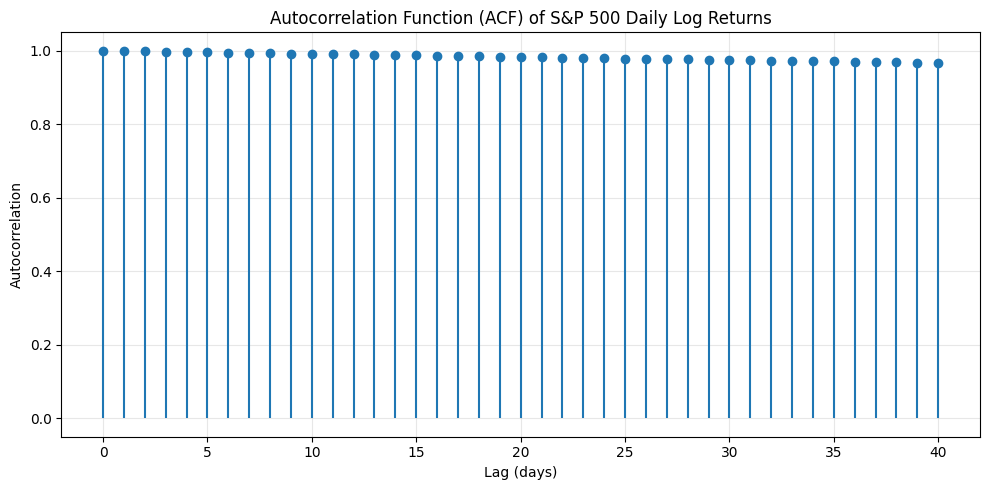

[1.         0.99912466 0.99825844 0.99737598 0.99649886 0.99563497
 0.99477385 0.99393324 0.99308985 0.99227601]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import acf

# Download S&P 500 data and compute daily log returns
data = yf.download('^GSPC', start='1990-01-01', end='2026-01-01', auto_adjust=False)
price = data['Adj Close'].dropna().squeeze()

# Compute ACF values for the first 40 lags
max_lag = 40
acf_values = acf(price, nlags=max_lag, fft=True)

# Plot ACF
lags = np.arange(len(acf_values))
plt.figure(figsize=(10, 5))
plt.stem(lags, acf_values, basefmt=' ', linefmt='tab:blue', markerfmt='o')
# plt.axhline(0, color='black', linewidth=1)
plt.title('Autocorrelation Function (ACF) of S&P 500 Daily Log Returns')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(acf_values[:10])